# Stage 07 — Segment & Treatment-Heterogeneity Analysis

Average treatment effects summarize all assigned customers; heterogeneity asks whether effects differ by customer characteristic. This can generate useful hypotheses, but many subgroup comparisons create false-positive risk. Stage 07 is exploratory, and Stage 05 remains the primary experiment analysis.

## 1. Segmentation rules and sample-size policy

Only one plausible pre-treatment characteristic at a time is used: channel, zip_code, newbie, history_segment, mens, and womens. Outcomes are never used to create segments; no arbitrary cutoffs or cross-product search is performed. A subgroup comparison is flagged if either arm has fewer than 1,000 observations. Conversion cells with fewer than five events in either arm are flagged as sparse and not treated as reliable evidence.

In [1]:
from hashlib import sha256
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from src.segmentation import add_fdr_interpretation, interaction_test, subgroup_treatment_effects

project_root = Path('.')
if not (project_root / 'data/processed/Hillstrom_clean.csv').exists(): project_root = Path('..')
raw_path = project_root / 'data/raw/Hillstrom.csv'
processed_path = project_root / 'data/processed/Hillstrom_clean.csv'
figure_dir = project_root / 'outputs/figures'
table_dir = project_root / 'outputs/tables'
control_group = 'No E-Mail'
treatment_groups = ['Mens E-Mail', 'Womens E-Mail']
segment_variables = ['channel', 'zip_code', 'newbie', 'history_segment', 'mens', 'womens']
plot_variables = ['channel', 'zip_code', 'newbie']
minimum_arm_size, sparse_event_threshold, bootstrap_resamples = 1000, 5, 1000

def file_sha256(path): return sha256(path.read_bytes()).hexdigest()
raw_hash_before, processed_hash_before = file_sha256(raw_path), file_sha256(processed_path)
data = pd.read_csv(processed_path)
overall_effects = pd.read_csv(project_root / 'outputs/tables/primary_treatment_effects.csv')
print('Loaded {:,} observations; spend bootstrap resamples: {:,}.'.format(len(data), bootstrap_resamples))

Loaded 64,000 observations; spend bootstrap resamples: 1,000.


## 2. Segment definitions

Observed categories, population shares, and treatment counts are displayed before estimating subgroup effects. zip_code is treated as its observed broad categorical variable, not assumed to contain literal postal ZIP codes. mens and womens are not interpreted as demographic gender.

In [2]:
definition_rows = []
for variable in segment_variables:
    counts = pd.crosstab(data[variable], data['segment'])
    print('\n{} treatment counts'.format(variable)); display(counts)
    for level, row in counts.iterrows():
        definition_rows.append({'Segment Variable':variable, 'Segment Level':level, 'Population N':int(row.sum()), 'Population Share (%)':row.sum()/len(data)*100, 'No E-Mail N':row[control_group], 'Mens E-Mail N':row['Mens E-Mail'], 'Womens E-Mail N':row['Womens E-Mail']})
segment_definitions = pd.DataFrame(definition_rows)
display(segment_definitions.round(2))


channel treatment counts


segment,Mens E-Mail,No E-Mail,Womens E-Mail
channel,,,
Multichannel,2577,2606,2579
Phone,9240,9327,9454
Web,9490,9373,9354



zip_code treatment counts


segment,Mens E-Mail,No E-Mail,Womens E-Mail
zip_code,,,
Rural,3243,3139,3181
Surburban,9501,9625,9650
Urban,8563,8542,8556



newbie treatment counts


...


mens treatment counts


segment,Mens E-Mail,No E-Mail,Womens E-Mail
mens,,,
0,9568,9519,9647
1,11739,11787,11740



womens treatment counts


segment,Mens E-Mail,No E-Mail,Womens E-Mail
womens,,,
0,9558,9638,9622
1,11749,11668,11765


,Segment Variable,Segment Level,Population N,Population Share (%),No E-Mail N,Mens E-Mail N,Womens E-Mail N
0,channel,Multichannel,7762,12.13,2606,2577,2579
1,channel,Phone,28021,43.78,9327,9240,9454
2,channel,Web,28217,44.09,9373,9490,9354
3,zip_code,Rural,9563,14.94,3139,3243,3181
4,zip_code,Surburban,28776,44.96,9625,9501,9650
5,zip_code,Urban,25661,40.10,8542,8563,8556
6,newbie,0,31856,49.78,10611,10621,10624
7,newbie,1,32144,50.22,10695,10686,10763
8,history_segment,1) $0 - $100,22970,35.89,7612,7724,7634
9,history_segment,2) $100 - $200,14254,22.27,4836,4691,4727


## 3. Subgroup effect estimates

Spend effects are treatment minus control mean spend per assigned customer with fixed-seed 1,000-resample percentile-bootstrap 95% intervals. Conversion and visit are absolute risk differences with Wald 95% intervals. Relative lift is supplementary because it can be unstable when control rates are small. These are estimates, not independent confirmatory discoveries.

In [3]:
rng = np.random.default_rng(20260918)
segment_effects = subgroup_treatment_effects(
    data,
    treatment_groups=treatment_groups,
    control_group=control_group,
    segment_variables=segment_variables,
    random_generator=rng,
    bootstrap_resamples=bootstrap_resamples,
    minimum_arm_size=minimum_arm_size,
    sparse_event_threshold=sparse_event_threshold,
)
display(segment_effects.head(12).round(5)); print('Subgroup comparisons:', len(segment_effects))


,Segment Variable,Segment Level,Treatment,Control,Outcome,Treatment N,Control N,Treatment Metric,Control Metric,Absolute Effect,Relative Lift,CI Lower,CI Upper,Sparse Event Flag,Small Arm Flag,Inference Method
0,channel,Multichannel,Mens E-Mail,No E-Mail,Spend,2577,2606,1.82487,0.61574,1.20913,1.96370,0.45780,2.02141,Not applicable,False,"1,000-resample percentile bootstrap CI"
1,channel,Multichannel,Mens E-Mail,No E-Mail,Conversion,2577,2606,0.01707,0.00691,0.01017,1.47195,0.00424,0.01609,False,False,Wald CI for proportion difference
2,channel,Multichannel,Mens E-Mail,No E-Mail,Visit,2577,2606,0.21149,0.12855,0.08294,0.64517,0.06260,0.10328,False,False,Wald CI for proportion difference
3,channel,Multichannel,Womens E-Mail,No E-Mail,Spend,2579,2606,1.77328,0.61574,1.15754,1.87991,0.33270,2.12498,Not applicable,False,"1,000-resample percentile bootstrap CI"
4,channel,Multichannel,Womens E-Mail,No E-Mail,Conversion,2579,2606,0.01396,0.00691,0.00705,1.02094,0.00152,0.01258,False,False,Wald CI for proportion difference
5,channel,Multichannel,Womens E-Mail,No E-Mail,Visit,2579,2606,0.17565,0.12855,0.04710,0.36640,0.02759,0.06661,False,False,Wald CI for proportion difference
6,channel,Phone,Mens E-Mail,No E-Mail,Spend,9240,9327,1.20853,0.64445,0.56407,0.87528,0.18270,1.00074,Not applicable,False,"1,000-resample percentile bootstrap CI"
7,channel,Phone,Mens E-Mail,No E-Mail,Conversion,9240,9327,0.01082,0.00536,0.00546,1.01883,0.00288,0.00804,False,False,Wald CI for proportion difference
8,channel,Phone,Mens E-Mail,No E-Mail,Visit,9240,9327,0.16277,0.08717,0.07560,0.86736,0.06615,0.08506,False,False,Wald CI for proportion difference
9,channel,Phone,Womens E-Mail,No E-Mail,Spend,9454,9327,0.87693,0.64445,0.23247,0.36073,-0.12967,0.60251,Not applicable,False,"1,000-resample percentile bootstrap CI"


Subgroup comparisons: 114


## 4. Interaction tests and FDR strategy

A subgroup effect being significant while another is not is not a valid heterogeneity test. For each treatment-control pair, interaction models test whether the treatment effect varies jointly across levels of a segmentation variable. Binary outcomes use logistic GLMs with HC3 robust covariance; spend uses an OLS mean model with HC3 robust covariance, an exploratory approach with clear zero-inflation/skewness limitations. Benjamini-Hochberg FDR correction is applied across all exploratory interaction tests.

In [4]:
interaction_rows = []
for outcome in ['spend','conversion','visit']:
    for treatment in treatment_groups:
        for variable in segment_variables:
            result = interaction_test(data, outcome, treatment, variable, control_group)
            interaction_rows.append({'Outcome':outcome.title(),'Treatment':treatment,'Segment Variable':variable,'Interaction Test':result['test_name'],'Raw P-Value':result['p_value'],'Model Status':result['model_status']})
interaction_tests = add_fdr_interpretation(pd.DataFrame(interaction_rows))
display(interaction_tests.round(6))


,Outcome,Treatment,Segment Variable,Interaction Test,Raw P-Value,Model Status,FDR Adjusted P-Value,Interpretation
0,Spend,Mens E-Mail,channel,OLS mean model HC3 robust joint Wald test,0.330245,Model fit successfully,0.540401,No interaction notable after FDR adjustment
1,Spend,Mens E-Mail,zip_code,OLS mean model HC3 robust joint Wald test,0.977013,Model fit successfully,0.984165,No interaction notable after FDR adjustment
2,Spend,Mens E-Mail,newbie,OLS mean model HC3 robust joint Wald test,0.188722,Model fit successfully,0.377445,No interaction notable after FDR adjustment
3,Spend,Mens E-Mail,history_segment,OLS mean model HC3 robust joint Wald test,0.512027,Model fit successfully,0.673460,No interaction notable after FDR adjustment
4,Spend,Mens E-Mail,mens,OLS mean model HC3 robust joint Wald test,0.320313,Model fit successfully,0.540401,No interaction notable after FDR adjustment
5,Spend,Mens E-Mail,womens,OLS mean model HC3 robust joint Wald test,0.589034,Model fit successfully,0.731215,No interaction notable after FDR adjustment
6,Spend,Womens E-Mail,channel,OLS mean model HC3 robust joint Wald test,0.166661,Model fit successfully,0.352929,No interaction notable after FDR adjustment
7,Spend,Womens E-Mail,zip_code,OLS mean model HC3 robust joint Wald test,0.214859,Model fit successfully,0.407100,No interaction notable after FDR adjustment
8,Spend,Womens E-Mail,newbie,OLS mean model HC3 robust joint Wald test,0.017748,Model fit successfully,0.091274,No interaction notable after FDR adjustment
9,Spend,Womens E-Mail,history_segment,OLS mean model HC3 robust joint Wald test,0.041700,Model fit successfully,0.115908,No interaction notable after FDR adjustment


## 5. Forest plots for selected interpretable segments

To avoid overcrowding, the forest plots use channel, zip_code, and newbie; all six specified variables remain in the results table. Spend effects are dollars per assigned customer; binary effects are percentage points. Mens and Womens effects are plotted separately.

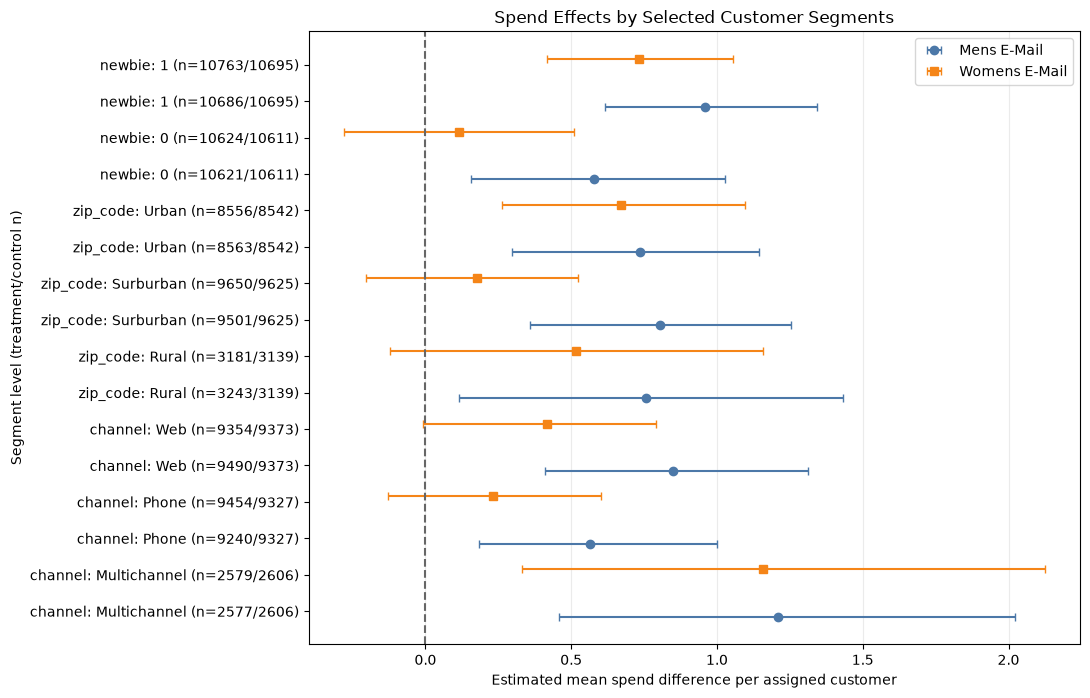

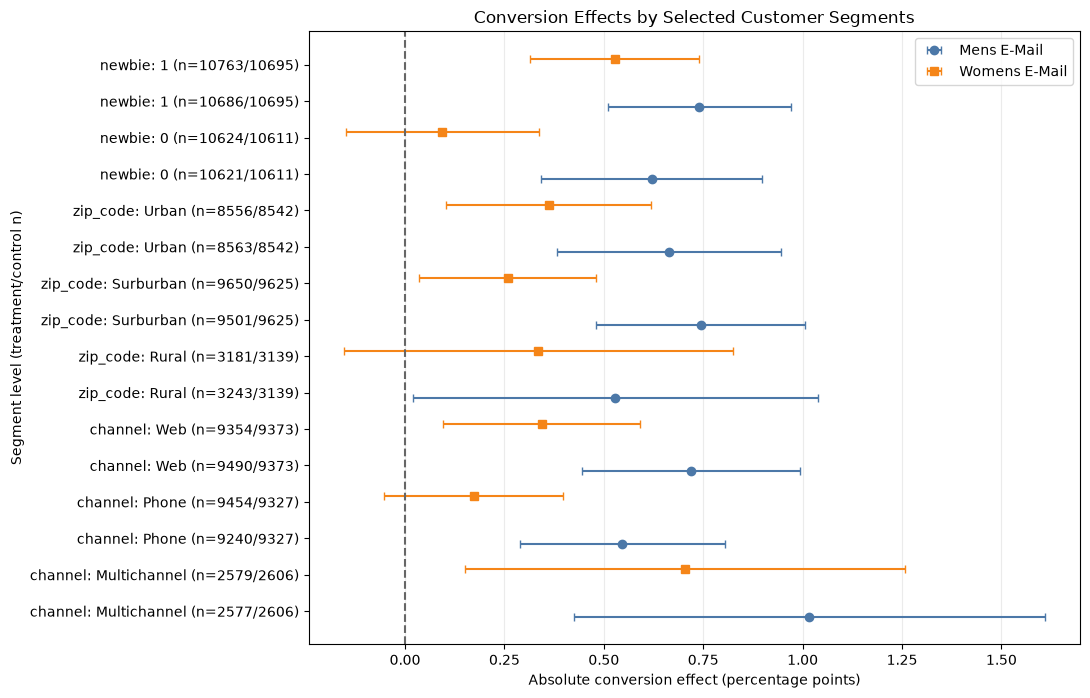

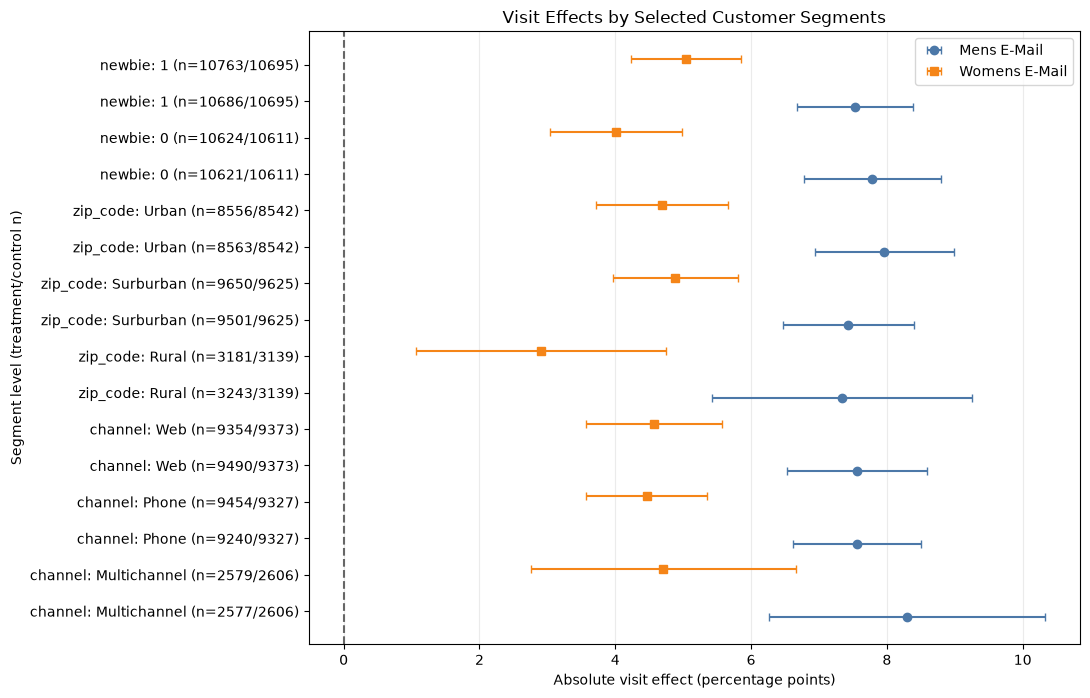

In [5]:
def subgroup_forest(outcome, filename, x_label):
    '''Create a readable selected-segment forest plot for one outcome.'''
    plot = segment_effects.loc[(segment_effects.Outcome == outcome) & (segment_effects['Segment Variable'].isin(plot_variables))].copy()
    plot['Label'] = plot['Segment Variable'] + ': ' + plot['Segment Level'].astype(str) + ' (n=' + plot['Treatment N'].astype(str) + '/' + plot['Control N'].astype(str) + ')'
    labels = list(dict.fromkeys(plot['Label'])); y = np.arange(len(labels)); fig, ax = plt.subplots(figsize=(11,max(6,.38*len(labels)+1)))
    for treatment,color,offset,marker in [('Mens E-Mail','#4C78A8',-.15,'o'),('Womens E-Mail','#F58518',.15,'s')]:
        part = plot.loc[plot.Treatment == treatment].set_index('Label').reindex(labels)
        effects = part['Absolute Effect'].to_numpy(); lower = effects-part['CI Lower'].to_numpy(); upper = part['CI Upper'].to_numpy()-effects
        scale = 100 if outcome != 'Spend' else 1
        ax.errorbar(effects*scale,y+offset,xerr=np.vstack([lower*scale,upper*scale]),fmt=marker,color=color,capsize=3,label=treatment)
    ax.axvline(0,color='#666666',linestyle='--'); ax.set_yticks(y,labels); ax.set_xlabel(x_label); ax.set_ylabel('Segment level (treatment/control n)'); ax.set_title('{} Effects by Selected Customer Segments'.format(outcome)); ax.grid(axis='x',alpha=.25); ax.legend(); plt.tight_layout(); fig.savefig(figure_dir/filename,dpi=160,bbox_inches='tight'); plt.show()

subgroup_forest('Spend','segment_spend_forest.png','Estimated mean spend difference per assigned customer')
subgroup_forest('Conversion','segment_conversion_forest.png','Absolute conversion effect (percentage points)')
subgroup_forest('Visit','segment_visit_forest.png','Absolute visit effect (percentage points)')

## 6. Sparse-event diagnostics and comparison with Stage 05

Sparse conversion cells, small-arm subgroup comparisons, and the overall Stage 05 effects are shown below. Visual variation around the overall effect is not itself evidence of heterogeneity. Relative lifts are supplementary, especially where baseline rates are very small.

In [6]:
sparse_conversion = segment_effects.loc[(segment_effects.Outcome == 'Conversion') & (segment_effects['Sparse Event Flag'] == True)]
small_arm = segment_effects.loc[segment_effects['Small Arm Flag'] == True]
print('Sparse conversion comparisons:', len(sparse_conversion)); display(sparse_conversion[['Segment Variable','Segment Level','Treatment','Treatment N','Control N','Treatment Metric','Control Metric','Absolute Effect']].round(5))
print('Small-arm comparisons:', len(small_arm))
overall_reference = overall_effects[['Outcome','Treatment','Absolute Effect']].rename(columns={'Absolute Effect':'Overall Stage 05 Effect'})
segment_vs_overall = segment_effects.merge(overall_reference,on=['Outcome','Treatment'])
display(segment_vs_overall[['Segment Variable','Segment Level','Treatment','Outcome','Absolute Effect','Overall Stage 05 Effect','CI Lower','CI Upper']].head(18).round(5))

Sparse conversion comparisons: 2


,Segment Variable,Segment Level,Treatment,Treatment N,Control N,Treatment Metric,Control Metric,Absolute Effect
79,history_segment,"6) $750 - $1,000",Mens E-Mail,644,622,0.02484,0.00482,0.02002
82,history_segment,"6) $750 - $1,000",Womens E-Mail,593,622,0.01349,0.00482,0.00867


Small-arm comparisons: 12


,Segment Variable,Segment Level,Treatment,Outcome,Absolute Effect,Overall Stage 05 Effect,CI Lower,CI Upper
0,channel,Multichannel,Mens E-Mail,Spend,1.20913,0.76983,0.45780,2.02141
1,channel,Multichannel,Mens E-Mail,Conversion,0.01017,0.00681,0.00424,0.01609
2,channel,Multichannel,Mens E-Mail,Visit,0.08294,0.07659,0.06260,0.10328
3,channel,Multichannel,Womens E-Mail,Spend,1.15754,0.42441,0.33270,2.12498
4,channel,Multichannel,Womens E-Mail,Conversion,0.00705,0.00311,0.00152,0.01258
5,channel,Multichannel,Womens E-Mail,Visit,0.04710,0.04523,0.02759,0.06661
6,channel,Phone,Mens E-Mail,Spend,0.56407,0.76983,0.18270,1.00074
7,channel,Phone,Mens E-Mail,Conversion,0.00546,0.00681,0.00288,0.00804
8,channel,Phone,Mens E-Mail,Visit,0.07560,0.07659,0.06615,0.08506
9,channel,Phone,Womens E-Mail,Spend,0.23247,0.42441,-0.12967,0.60251


## 7. Outputs, limitations, and Stage 07 findings

The full effect table and interaction summary are saved below. Limitations include exploratory segmentation not known to be pre-specified, multiple testing, sparse conversion cells, wider subgroup uncertainty, no customer identifier, no timestamp, unknown outcome window, imperfect covariate definitions, and uncertain generalization. Any pattern worth pursuing should be validated in a future experiment; no targeting recommendation is made.

In [7]:
segment_effects.to_csv(table_dir/'segment_treatment_effects.csv',index=False)
interaction_tests.to_csv(table_dir/'interaction_tests.csv',index=False)
print('Saved subgroup-effect and interaction-test tables.')
print('Raw interaction p-values below 0.05:', int((interaction_tests['Raw P-Value'] < .05).sum()))
print('Interactions surviving FDR:', int((interaction_tests['FDR Adjusted P-Value'] < .05).sum()))
display(interaction_tests.loc[interaction_tests['Raw P-Value'] < .05].sort_values('Raw P-Value').round(6))

Saved subgroup-effect and interaction-test tables.
Raw interaction p-values below 0.05: 13
Interactions surviving FDR: 6


,Outcome,Treatment,Segment Variable,Interaction Test,Raw P-Value,Model Status,FDR Adjusted P-Value,Interpretation
35,Visit,Womens E-Mail,womens,Logistic GLM robust joint Wald test,0.000000,Model fit successfully,0.000000,Exploratory interaction notable after FDR adju...
34,Visit,Womens E-Mail,mens,Logistic GLM robust joint Wald test,0.000000,Model fit successfully,0.000000,Exploratory interaction notable after FDR adju...
32,Visit,Womens E-Mail,newbie,Logistic GLM robust joint Wald test,0.000057,Model fit successfully,0.000681,Exploratory interaction notable after FDR adju...
26,Visit,Mens E-Mail,newbie,Logistic GLM robust joint Wald test,0.000482,Model fit successfully,0.004342,Exploratory interaction notable after FDR adju...
20,Conversion,Womens E-Mail,newbie,Logistic GLM robust joint Wald test,0.001489,Model fit successfully,0.010722,Exploratory interaction notable after FDR adju...
31,Visit,Womens E-Mail,zip_code,Logistic GLM robust joint Wald test,0.004845,Model fit successfully,0.029072,Exploratory interaction notable after FDR adju...
8,Spend,Womens E-Mail,newbie,OLS mean model HC3 robust joint Wald test,0.017748,Model fit successfully,0.091274,No interaction notable after FDR adjustment
25,Visit,Mens E-Mail,zip_code,Logistic GLM robust joint Wald test,0.027217,Model fit successfully,0.112088,No interaction notable after FDR adjustment
14,Conversion,Mens E-Mail,newbie,Logistic GLM robust joint Wald test,0.028587,Model fit successfully,0.112088,No interaction notable after FDR adjustment
23,Conversion,Womens E-Mail,womens,Logistic GLM robust joint Wald test,0.031136,Model fit successfully,0.112088,No interaction notable after FDR adjustment


# Stage 07 Findings

All six pre-specified customer characteristics were analyzed one at a time. The full table reports descriptive subgroup effects and intervals, while interaction models—not differences in subgroup significance—are used for heterogeneity claims. Raw interaction signals are evaluated only after Benjamini-Hochberg FDR correction.

Subgroup estimates should be viewed as exploratory and generally compared with Stage 05 overall effects. Sparse conversion events and small treatment arms increase uncertainty in some history segments. Any FDR-notable interaction is a candidate for validation in a future experiment, not a targeting conclusion. Stage 05 remains the primary analysis; no treatment winner or business recommendation is made.

## 8. File-integrity confirmation

In [8]:
print('Raw dataset unchanged during notebook execution:', raw_hash_before == file_sha256(raw_path))
print('Processed dataset unchanged during notebook execution:', processed_hash_before == file_sha256(processed_path))
print('Segmentation variables used:', segment_variables)
print('Post-treatment variables used for segmentation: none')
print('Stage 05 remains the primary analysis; Stage 07 interaction claims use FDR-adjusted tests.')

Raw dataset unchanged during notebook execution: True
Processed dataset unchanged during notebook execution: True
Segmentation variables used: ['channel', 'zip_code', 'newbie', 'history_segment', 'mens', 'womens']
Post-treatment variables used for segmentation: none
Stage 05 remains the primary analysis; Stage 07 interaction claims use FDR-adjusted tests.
